<a href="https://colab.research.google.com/github/shakshi-k/My_projects/blob/Other-fantastic-projects/Credit_card_k_means_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1) Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# 2) Uploading dataset
from google.colab import files
uploaded = files.upload()

Saving Credit Card Customer Data.csv to Credit Card Customer Data.csv


In [3]:
# 3) Getting the information on the dataset.
df = pd.read_csv("Credit Card Customer Data.csv")
df.head()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1,87073,100000,2,1,1,0
1,2,38414,50000,3,0,10,9
2,3,17341,50000,7,1,3,4
3,4,40496,30000,5,1,1,4
4,5,47437,100000,6,0,12,3


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660 entries, 0 to 659
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Sl_No                660 non-null    int64
 1   Customer Key         660 non-null    int64
 2   Avg_Credit_Limit     660 non-null    int64
 3   Total_Credit_Cards   660 non-null    int64
 4   Total_visits_bank    660 non-null    int64
 5   Total_visits_online  660 non-null    int64
 6   Total_calls_made     660 non-null    int64
dtypes: int64(7)
memory usage: 36.2 KB


In [6]:
df.isnull().sum()

,0
Sl_No,0
Customer Key,0
Avg_Credit_Limit,0
Total_Credit_Cards,0
Total_visits_bank,0
Total_visits_online,0
Total_calls_made,0


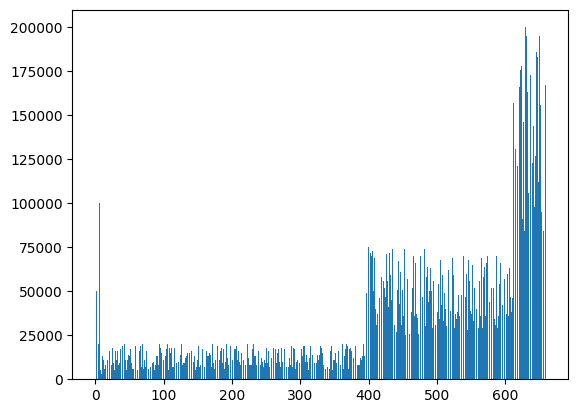

In [16]:
# 4) Visualizing the dataset
plt.bar(x = df.index, height = df['Avg_Credit_Limit'])
plt.show()

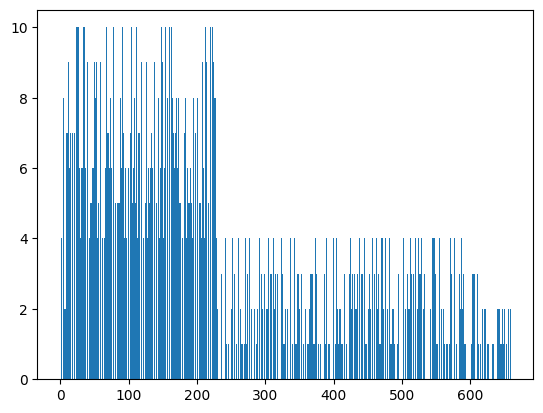

In [18]:
plt.bar(x = df.index, height = df['Total_calls_made'])
plt.show()

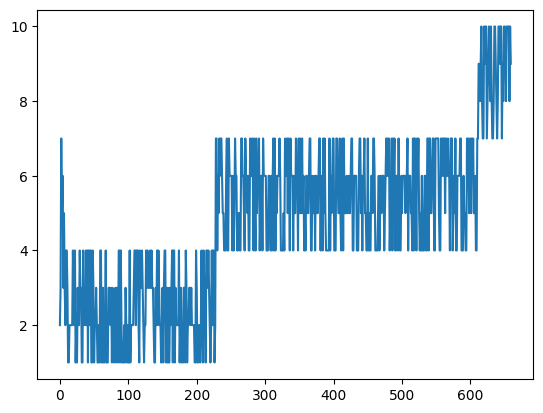

In [24]:
plt.plot(df.index, df['Total_Credit_Cards'])
plt.show()

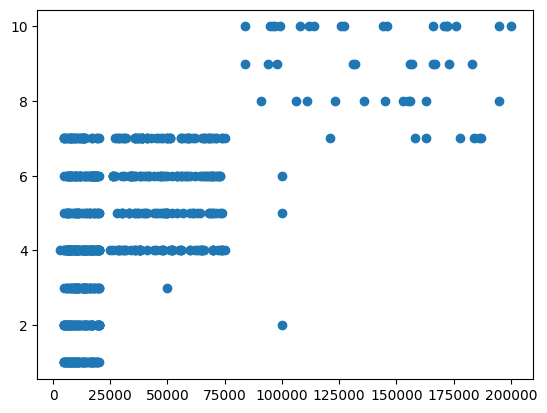

In [34]:
plt.scatter(df['Avg_Credit_Limit'] , df['Total_Credit_Cards'])
plt.show()

In [48]:
# 5) We will do k means Clustering
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [40]:
# 6) Drop Non-informative Columns
features = df.drop(columns = ['Customer Key', 'Sl_No'])

In [41]:
# 7) Standardize the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [44]:
# 8) Use Elbow method to choose optimal k
inertias = []
k_range = range(1, 11)

for k in k_range:
  kmeans = KMeans(n_clusters = k, random_state = 42)
  kmeans.fit(scaled_features)
  inertias.append(kmeans.inertia_)

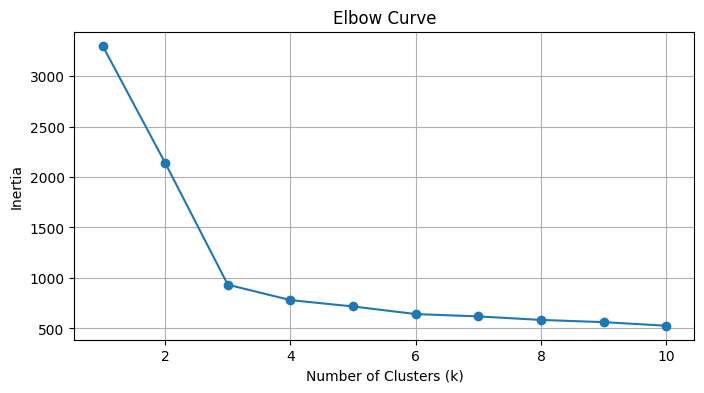

In [45]:
# 9) Plot the Elbow curve
plt.figure(figsize = (8, 4))
plt.plot(k_range, inertias, marker = 'o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Curve')
plt.grid(True)
plt.show()

In [46]:
# 10) Apply Kmeans with optimal K
optimal_k = 3
kmeans = KMeans(n_clusters = optimal_k, random_state = 42)
labels = kmeans.fit_predict(scaled_features)

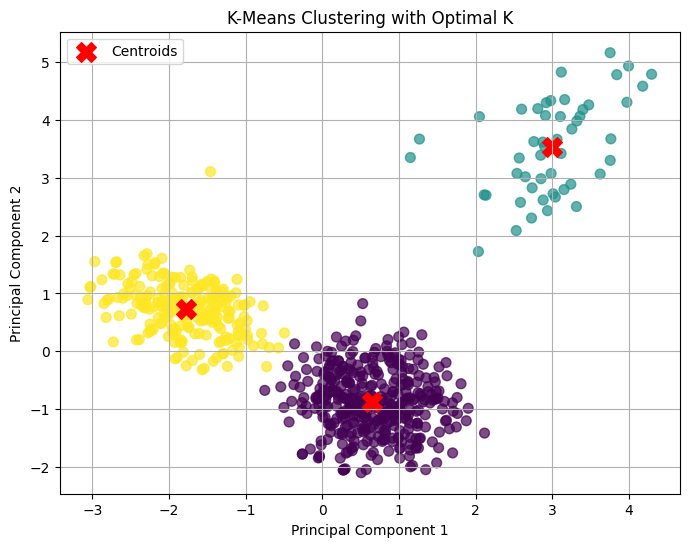

In [49]:
# 11) Visualize clusters using PCA
pca = PCA(n_components = 2)
reduced_features = pca.fit_transform(scaled_features)
reduced_centroids = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize = (8, 6))
plt.scatter(reduced_features[:, 0], reduced_features[:, 1], c = labels, cmap = 'viridis', s = 50, alpha = 0.7)
plt.scatter(reduced_centroids[:, 0], reduced_centroids[:, 1], c = 'red', s = 200, marker = 'X', label = 'Centroids')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-Means Clustering with Optimal K')
plt.legend()
plt.grid(True)
plt.show()

In [51]:
# 12) View clustervise Summary
df['Cluster'] = labels
cluster_summary = df.groupby('Cluster').mean()
print(cluster_summary)

              Sl_No  Customer Key  Avg_Credit_Limit  Total_Credit_Cards  \
Cluster                                                                   
0        417.528497  54881.329016      33782.383420            5.515544   
1        611.280000  56708.760000     141040.000000            8.740000   
2        117.857143  55239.830357      12174.107143            2.410714   

         Total_visits_bank  Total_visits_online  Total_calls_made  
Cluster                                                            
0                 3.489637             0.981865          2.000000  
1                 0.600000            10.900000          1.080000  
2                 0.933036             3.553571          6.870536  
